[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/WCC-Engineering/ENGR240/blob/week2-worksheet/Class%20Demos%20and%20Activities/Week%202/worksheet1_complete.ipynb)

# Worksheet 2.1: Loops and Series Calculations

## ENGR& 240: Engineering Computations
### Introduction to Scientific Computing with Python

## Objectives
- Understand for loops and how they're used in scientific computing
- Analyze code that computes terms in a geometric series
- Implement and visualize infinite series calculations
- Practice tracing execution of loops in Python code

## Instructions

This worksheet focuses on understanding and implementing series calculations using loops in Python. We'll examine a geometric series function, trace its execution, and then extend the concept to another important series.

A geometric series is a sum where each term is found by multiplying the previous term by a fixed, non-zero number called the common ratio. In our case, we'll be looking at the series:

$$\sum_{k=1}^{\infty} \frac{1}{2^k} = \frac{1}{2} + \frac{1}{4} + \frac{1}{8} + \frac{1}{16} + \ldots$$

This is a common series in engineering and science with a known sum of 1 as the number of terms approaches infinity.

## Part 1: Understanding the Geometric Series Function

Below is a Python function that calculates the first N terms of a geometric series with a ratio of 1/2, as well as the cumulative sum of these terms. Study the code, then answer the questions that follow.

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def geom2(N):
    """
    [series_vector, series_sums] = geom2(N)

    Outputs a vector of the first N terms of the geometric series given by

        x_k = 1/2^k

    Also outputs a second vector of the first N series sums

    Parameters:
    -----------
    N : int
        Number of terms in the series

    Returns:
    --------
    series_vector : ndarray
        Vector containing the first N terms of the geometric series
    series_sums : ndarray
        Vector containing the cumulative sums of the series
    """

    # Initialize arrays with the first term
    series_vector = np.zeros(N)
    series_sums = np.zeros(N)

    # Set the first term
    series_vector[0] = 0.5  # 1/2^1
    series_sums[0] = series_vector[0]

    # Calculate remaining terms
    for k in range(1, N):
        series_vector[k] = 1/(2**(k+1))  # Note: we use k+1 because Python is 0-indexed
        series_sums[k] = series_sums[k-1] + series_vector[k]
    return series_vector, series_sums

geom2(5)

(array([0.5    , 0.25   , 0.125  , 0.0625 , 0.03125]),
 array([0.5    , 0.75   , 0.875  , 0.9375 , 0.96875]))

### Variable Tracing

Let's trace through the execution of this function for `N = 5`. Fill in the table below to track how the variables change as the loop iterates. The first row is done for you.

| Loop Iteration | k | series_vector[k] | series_sums[k] |
|---------------|---|------------------|----------------|
| Before loop | - | [0.5, 0, 0, 0, 0] | [0.5, 0, 0, 0, 0] |
| Iteration 1 | 1 |[0.5, 0.25, 0, 0, 0] |[0.5, 0.75, 0, 0, 0] |
| Iteration 2 | 2 | [0.5, 0.25, 0.125, 0, 0]|[0.5, 0.75, 0.875, 0, 0]|
| Iteration 3 | 3 | [0.5, 0.25, 0.125, 0.0625, 0]|[0.5, 0.75, 0.875, 0.9375, 0]|
| Iteration 4 | 4 | [0.5, 0.25, 0.125, 0.0625, 0.03125]|[0.5, 0.75, 0.875, 0.9375, 0.96875]|

Now, let's test the function with `N = 10` and print the results:

In [53]:
# Test the geom2 function with N = 10
terms, sums = geom2(9)

# Print the results
print("Terms of the geometric series:")
print(terms)
print("\nCumulative sums:")
print(sums)

Terms of the geometric series:
[0.5        0.25       0.125      0.0625     0.03125    0.015625
 0.0078125  0.00390625 0.00195312]

Cumulative sums:
[0.5        0.75       0.875      0.9375     0.96875    0.984375
 0.9921875  0.99609375 0.99804688]


Let's visualize both the individual terms and the cumulative sums:

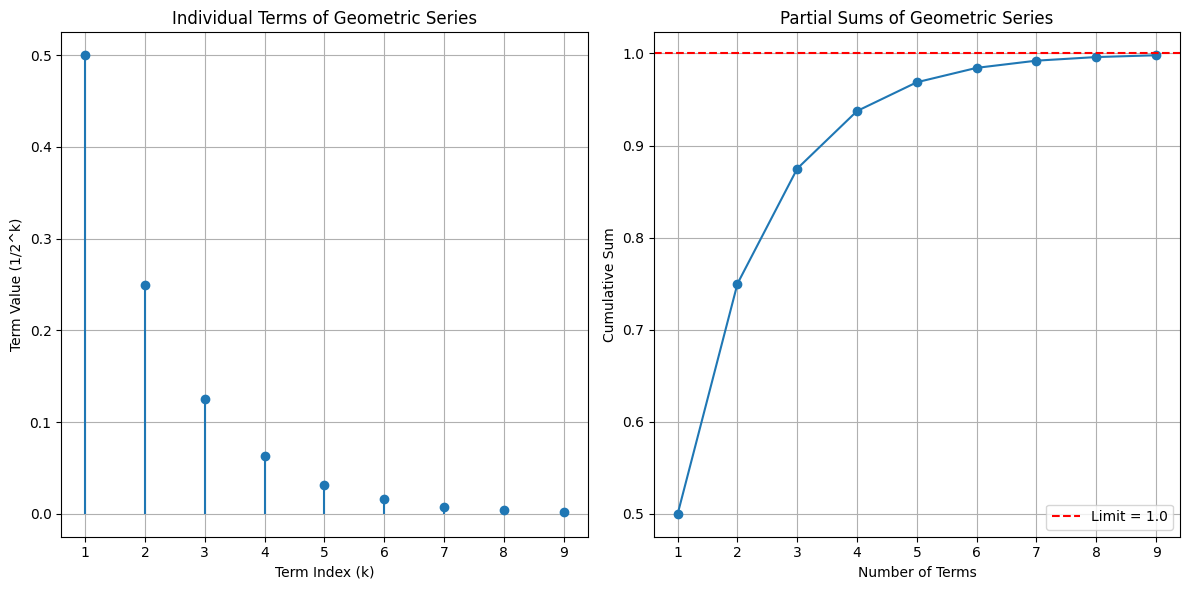

In [52]:
# Visualize the geometric series with N = 20
N = 20
terms, sums = geom2(N)

# Create term indices for plotting (1 to N)
indices = np.arange(1, N+1)

# Create a figure with two subplots
plt.figure(figsize=(12, 6))

# Plot the individual terms
plt.subplot(1, 2, 1)
plt.stem(indices, terms, basefmt=" ")
plt.xlabel('Term Index (k)')
plt.ylabel('Term Value (1/2^k)')
plt.title('Individual Terms of Geometric Series')
plt.grid(True)

# Plot the cumulative sum
plt.subplot(1, 2, 2)
plt.plot(indices, sums, 'o-')
plt.axhline(y=1.0, color='r', linestyle='--', label='Limit = 1.0')
plt.xlabel('Number of Terms')
plt.ylabel('Cumulative Sum')
plt.title('Partial Sums of Geometric Series')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Conceptual Questions

Answer the following questions about the geometric series function:

1. What is the purpose of initializing `series_vector` and `series_sums` as arrays of zeros? Why not start with empty arrays?
* In order to create an array of a set size N that doesn't change with the iterations.

2. What would happen if we changed the loop to start from 0 instead of 1? What adjustments would we need to make to the code?
* Each k in an indices, would require a corresponding offset. [k - 1] → [k]

3. The formula for the sum of an infinite geometric series with first term a and common ratio r (where |r| < 1) is:
   $$S_{\infty} = \frac{a}{1-r}$$
   Calculate the theoretical sum for our series and compare it to the value of `sums[N-1]` for large N. How close does our numerical calculation get to the theoretical value?
* The theoretical value for the convergence is 1. sums[9] = 0.99804688, so the margin of error is ~0.002

## Part 2: Alternating Series - The Leibniz Series

Now, we'll consider an interesting alternating series called the Leibniz series, which is used to approximate π:

$$\frac{\pi}{4} = 1 - \frac{1}{3} + \frac{1}{5} - \frac{1}{7} + \frac{1}{9} - \ldots = \sum_{k=0}^{\infty} \frac{(-1)^k}{2k+1}$$

Your task is to implement a function called `leibniz_series(N)` that calculates the first N terms of this series and returns both the individual terms and the cumulative sum (which approximates π/4).

In [39]:
def leibniz_series(N):
  terms = np.zeros(N)
  partial_sums = np.zeros(N)
#First Term
  terms[0] = 1
  partial_sums[0] = 1

  """
    Calculate the first N terms of the Leibniz series and their cumulative sum.

    The Leibniz series is: 1 - 1/3 + 1/5 - 1/7 + ... = π/4

    Parameters:
    -----------
    N : int
        Number of terms to calculate

    Returns:
    --------
    terms : ndarray
        Array of the first N terms of the series
    partial_sums : ndarray
        Array of the cumulative sums (approximations of π/4)
  """
  for n in range(0, N):
    terms[n] = ((-1)**n)/(2*n + 1)
    partial_sums[n] = terms[n] + partial_sums[n-1]

  return terms, partial_sums

Once you've implemented the function, use it to calculate and visualize the series. How many terms do you need to get a good approximation of π?

In [40]:
# Test your leibniz_series function
true_term_values = [1, -1/3, 1/5, -1/7, 1/9]
term_error = np.zeros(5)
print("Deviation Error")
for v in range(0,len(true_term_values)):
  term_error[v] = true_term_values[v] - leibniz_series(5)[0][v]
  print(f"term {v+1}:\t{term_error[v]}")




Deviation Error
term 1:	0.0
term 2:	0.0
term 3:	0.0
term 4:	0.0
term 5:	0.0


### Visualizing Convergence to π

Create a visualization that shows both the individual terms and how the cumulative sum converges to π/4 (or multiply by 4 to show convergence to π directly).

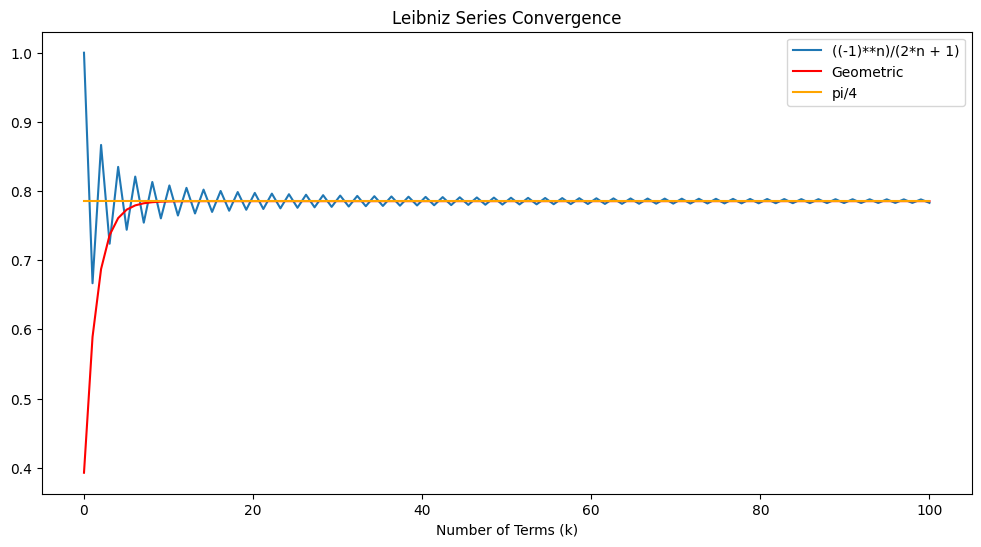

In [51]:
# Visualize the Leibniz series and its convergence to π/4
max_term_count = 100
x_values = np.linspace(0,max_term_count,max_term_count)
target_line = np.full_like(np.zeros(max_term_count),np.pi/4)


plt.figure(figsize=(12,6))
plt.plot(x_values,leibniz_series(max_term_count)[1],label="((-1)**n)/(2*n + 1)")
plt.plot(x_values,(np.pi/4)*geom2(max_term_count)[1],label="Geometric",color="red")
plt.plot(x_values,target_line,color="orange",label="pi/4")
plt.xlabel("Number of Terms (k)")
plt.title("Leibniz Series Convergence")
plt.legend()
plt.show()

## Reflection

After completing this worksheet, answer the following questions:

1. How does the geometric series converge compared to the Leibniz series? Which one converges faster?
* The geometic series converges considerably faster than the Leibniz series with a logarithmic shape rather than a jagged over-under.

2. What are the advantages of using array operations versus loops in Python for these calculations?
* Array operations allow for more robust and efficiencent handling for a large data set.

3. Can you think of ways to improve the efficiency of the Leibniz series calculation? (Hint: Consider vectorization using NumPy.)
* k = np.arange(N)<br>
terms = ((-1)**k) / (2*k + 1)<br>
pi_approx = 4 * np.sum(terms)